## Setup Packages

In [ ]:
!pip install sentence-transformers
!pip install textblob

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 434.9 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 2.7 MB/s eta 0:00:00
  Created wheel for sentence-transformers: filename=sentence_transformers-2.2.2-py3-none-any.whl size=125923 sha256=2c634e3ebe1cf8ed6937d3e2cb4bd99baf03d8c7a36ff78b2898683b4c7390f8
  Stored in directory: /root/.cache/pip/wheels/62/f2/10/1e606fd5f02395388f74e7462910fe851042f97238cbbd902f
Successfully built sentence-transformers


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
import pandas as pd
import numpy as np
import re
import string
import textblob
from sentence_transformers import SentenceTransformer
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt
import seaborn as sns

import pickle

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from transformers import TFAutoModelForSequenceClassification
from transformers import AutoTokenizer, AutoConfig
from transformers import BertTokenizer, BertModel, TFBertModel
#from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForMaskedLM

import tensorflow as tf
from tensorflow.keras.optimizers import Adam

import os
import joblib
import random
from sklearn import metrics
from sklearn.metrics import f1_score
import gdown

In [ ]:
import os
from pathlib import Path

remote=True
if remote:
  # GDrive Access
  from google.colab import drive
  drive.mount('/content/drive')

  # FILES PATHS
  global BASE_PATH
  BASE_PATH = Path('/content/drive/My Drive/Colab Projects/AI Public Trust')
  global DATA_DIR
  DATA_DIR = BASE_PATH / 'Data Sets' / 'Classifiers'
  global MODELS_DIR
  MODELS_DIR = BASE_PATH / 'Models' / 'Classifiers'

  DATA_DIR.mkdir(parents=True, exist_ok=True)
  MODELS_DIR.mkdir(parents=True, exist_ok=True)
  print("Data Directory:", DATA_DIR)
  print("Models Directory:", MODELS_DIR)


Mounted at /content/drive
Current Directory: /content/drive/My Drive/Colab Projects/Social Generics with Uwe/Computational Side/Model Training/Code
Parent Directory: /content/drive/My Drive/Colab Projects/Social Generics with Uwe/Computational Side/Model Training
/content/drive/My Drive/Colab Projects/Social Generics with Uwe/Computational Side/Model Training/Saved Models/
/content/drive/My Drive/Colab Projects/Social Generics with Uwe/Computational Side/Model Training/Data Sets/


## Load the Training Data

In [ ]:
REBUILD_DATA = True
import pandas as pd

if REBUILD_DATA:
    # Google Sheets URLs
    basic_url = 'https://drive.google.com/uc?id=17eYOl_TzUCxR5ADZ5zCXbjaShukaLzRA'
    all_url = 'https://drive.google.com/uc?id=14MBjGtjkNHCo0aTqPTvDYlik62ptZfVF'
    random_url = 'https://drive.google.com/uc?id=1-3FPYj7laX28VMV3JJ0in41HEIY3FpkC'
    selected_url = 'https://drive.google.com/uc?id=1ENhgf4vRrLHFQVWIdjiaU8susNnkmpJg'

    print("Downloading from Google Drive...")
    basic_generics_df = pd.read_excel(basic_url)
    synthetic_data = pd.read_csv(all_url)
    twitter_selected_generics_df = pd.read_excel(selected_url)
    random_twits_df = pd.read_excel(random_url)
else:
    print("Loading locally from DATA_DIR...")
    # This relies on the CSVs created in the next steps
    pass  # We will just load the final consolidated CSV


In [ ]:
print(len(basic_generics_df))
print(len(synthetic_data))
print(len(twitter_selected_generics_df))
print(len(random_twits_df))

2000
6201
2000
4000


### Create CSVs

In [ ]:
if REBUILD_DATA:
    print("Saving raw dataframes to CSV...")
    basic_generics_df.to_csv(DATA_DIR / 'basic_generics.csv', index=False)
    random_twits_df.to_csv(DATA_DIR / 'random_twits.csv', index=False)
    twitter_selected_generics_df.to_csv(DATA_DIR / 'selected_twits.csv', index=False)
    synthetic_data.to_csv(DATA_DIR / 'synthetic_data_raw.csv', index=False)


In [ ]:
print(basic_generics_df.dtypes)
basic_generics_df.head()

Social generic: 0 = no, 1 = yes     int64
Example statements                 object
dtype: object


,"Social generic: 0 = no, 1 = yes",Example statements
0,1,People rarely expect an explanation that consi...
1,1,Users overwhelmingly prefer natural language e...
2,1,Humans usually do not build trust in abstract ...
3,1,Ordinary Americans increasingly dislike and di...
4,1,U.S. liberals and conservatives not only disag...


In [ ]:
print(random_twits_df.dtypes)
random_twits_df.head()

Social generic: 0 = no, 1 = yes     int64
Potential Generic                  object
Twid                                int64
dtype: object


,"Social generic: 0 = no, 1 = yes",Potential Generic,Twid
0,0,"When I was cheering for the #Celtics Sunday, i...",1516065109151518976
1,0,God is the black woman? Well I’ll be damned. T...,1516065094513345024
2,0,"Red, the blood of angry men,\nBlack, the dark ...",1516065091573240064
3,1,With all the proof and evidence of corruption ...,1516065088871883008
4,0,Our Feature: The Witty Actual Fucking Nazi Who...,1516065079707542016


In [ ]:
print(twitter_selected_generics_df.dtypes)
twitter_selected_generics_df.head()

Scoial generic: 0 = no, 1 = yes     int64
Potential Generic                  object
Twid                                int64
dtype: object


,"Scoial generic: 0 = no, 1 = yes",Potential Generic,Twid
0,0,Anyone who listens to Old Senile and elects m...,1572990102242225920
1,1,white people be making actual points but rando...,1556047723438247936
2,1,"""women who are taking hormones to be men"" tran...",1548809394820787968
3,0,Everyone should be ashamed to call ourselves a...,1582122669558104064
4,0,Anyone who makes trans kids lives harder reall...,1499522825601700096


In [ ]:
first_column_name=twitter_selected_generics_df.columns[0]

## Clean Text

In [ ]:
# Load and clean up the data
def clean_tweet(tweet):
    tweet = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*(),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', tweet) #remove hyperlinks
    tweet = re.sub(r'@[A-Za-z0-9]+', '', tweet) #remove usernames
    #s=re.sub(r'@\w+', '', s)
    #tweet = re.sub(r'#[A-Za-z0-9]+', '', tweet) #remove hashtages
    tweet = tweet.replace('#',"")
    tweet = re.sub(r'\b(?:RT )?\b', '', tweet) #remove retweet indicators if present
    tweet = re.sub(r'\n', ' ', tweet) #replace new line with space
    tweet = re.sub(r'\s+', ' ', tweet) # replace multiple spaces with one space
    tweet = ''.join(c for c in tweet if c not in string.punctuation) #remove punctuation
    # Spelling correction
    #tweet = textblob.TextBlob(tweet).correct().string
    return tweet.strip().lower()


In [ ]:
if REBUILD_DATA:
    import re
    import string
    import numpy as np

    def clean_tweet(tweet):
        if not isinstance(tweet, str):
            return ""
        tweet = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*(),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', tweet) #remove hyperlinks
        tweet = re.sub(r'@[A-Za-z0-9]+', '', tweet) #remove usernames
        tweet = tweet.replace('#',"")
        tweet = re.sub(r'\b(?:RT )?\b', '', tweet) #remove retweet indicators if present
        tweet = re.sub(r'\n', ' ', tweet) #replace new line with space
        tweet = re.sub(r'\s+', ' ', tweet) # replace multiple spaces with one space
        # remove punctuation but keep internal hyphens or apostrophes if needed, standard code:
        tweet = ''.join(c for c in tweet if c not in string.punctuation) #remove punctuation
        return tweet.strip().lower()

    # Structure lists to merge into one training dataframe
    # basic_generics_df columns: Social generic: 0 = no, 1 = yes; Example statements
    df1 = pd.DataFrame({
        'text': basic_generics_df['Example statements'].apply(clean_tweet),
        'label': basic_generics_df.iloc[:, 0].astype(int),
        'source': 'basic_generics'
    })

    df2 = pd.DataFrame({
        'text': twitter_selected_generics_df['Potential Generic'].astype(str).apply(clean_tweet),
        'label': twitter_selected_generics_df.iloc[:, 0].astype(int),
        'source': 'twitter_selected_generics'
    })

    df3 = pd.DataFrame({
        'text': random_twits_df['Potential Generic'].astype(str).apply(clean_tweet),
        'label': random_twits_df.iloc[:, 0].astype(int),
        'source': 'random_twits'
    })

    training_df = pd.concat([df1, df2, df3], ignore_index=True)
    # Drop empties
    training_df = training_df[training_df['text'].str.strip() != '']
    
    # Synthetic data
    # synthetic_data columns: 'tweets', integer label as second column (usually)
    synth_df = pd.DataFrame({
        'text': synthetic_data['tweets'].apply(clean_tweet),
        'label': synthetic_data.iloc[:, 1].astype(int),
        'source': 'synthetic'
    })
    # Drop empties
    synth_df = synth_df[synth_df['text'].str.strip() != '']
    
    # Save the consolidated CSVs
    print("Saving consolidated datasets...")
    training_df.to_csv(DATA_DIR / 'classification_training_data.csv', index=False)
    synth_df.to_csv(DATA_DIR / 'classification_synthetic_data.csv', index=False)
else:
    print("Loading pre-built consolidated data...")
    training_df = pd.read_csv(DATA_DIR / 'classification_training_data.csv')
    synth_df = pd.read_csv(DATA_DIR / 'classification_synthetic_data.csv')


In [ ]:
basic_generics_df.head()

,"Social generic: 0 = no, 1 = yes",Example statements,cleaned_tweets
0,1,People rarely expect an explanation that consi...,people rarely expect an explanation that consi...
1,1,Users overwhelmingly prefer natural language e...,users overwhelmingly prefer natural language e...
2,1,Humans usually do not build trust in abstract ...,humans usually do not build trust in abstract ...
3,1,Ordinary Americans increasingly dislike and di...,ordinary americans increasingly dislike and di...
4,1,U.S. liberals and conservatives not only disag...,us liberals and conservatives not only disagre...


In [ ]:
random_twits_df.head()

,"Social generic: 0 = no, 1 = yes",Potential Generic,Twid,cleaned_tweets
0,0,"When I was cheering for the #Celtics Sunday, i...",1516065109151518976,when i was cheering for the celtics sunday it ...
1,0,God is the black woman? Well I’ll be damned. T...,1516065094513345024,god is the black woman well i’ll be damned tea...
2,0,"Red, the blood of angry men,\nBlack, the dark ...",1516065091573240064,red the blood of angry men black the dark of a...
3,1,With all the proof and evidence of corruption ...,1516065088871883008,with all the proof and evidence of corruption ...
4,0,Our Feature: The Witty Actual Fucking Nazi Who...,1516065079707542016,our feature the witty actual fucking nazi who ...


In [ ]:
twitter_selected_generics_df.head()

,"Scoial generic: 0 = no, 1 = yes",Potential Generic,Twid,cleaned_tweets
0,0,Anyone who listens to Old Senile and elects m...,1572990102242225920,anyone who listens to old senile and elects mo...
1,1,white people be making actual points but rando...,1556047723438247936,white people be making actual points but rando...
2,1,"""women who are taking hormones to be men"" tran...",1548809394820787968,women who are taking hormones to be men trans ...
3,0,Everyone should be ashamed to call ourselves a...,1582122669558104064,everyone should be ashamed to call ourselves a...
4,0,Anyone who makes trans kids lives harder reall...,1499522825601700096,anyone who makes trans kids lives harder reall...


## Get Sentences, Labels, their Embeddings, and train-test splits

In [ ]:
## Generate Lists
global sentences
sentences = training_df['text'].tolist()
global labels
import numpy as np
labels = np.array(training_df['label'].tolist())

synthetic_sentences = synth_df['text'].tolist()
synthetic_labels = np.array(synth_df['label'].tolist())

print("Training samples:", len(sentences))
print("Synthetic samples:", len(synthetic_sentences))


In [ ]:
np.unique(labels, axis=0)

array([0, 1])

### Sentence Embeddings

- From Huggingface
- Bag of Words

#### Hugging Face Embedding

In [ ]:
# Generate sentence embeddings
model = SentenceTransformer("all-mpnet-base-v2")
embeddings = model.encode(sentences)
synthetic_embeddings = model.encode(synthetic_sentences)

.gitattributes:   0%|          | 0.00/1.18k [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

train_script.py:   0%|          | 0.00/13.1k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

In [ ]:
print(len(embeddings)==len(basic_generics_df)+len(twitter_selected_generics_df)+len(random_twits_df))
len(embeddings)

True


8000

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.2,shuffle=True)

X_training_plus_synthetic = np.concatenate((X_train, synthetic_embeddings))
y_training_plus_synthetic = np.concatenate((y_train, synthetic_labels))


# Train the LightGBM model
training_plus_synthetic_data = lgb.Dataset(X_training_plus_synthetic,label=y_training_plus_synthetic)
train_data = lgb.Dataset(X_train, label=y_train)
synthetic_train_data = lgb.Dataset(synthetic_embeddings,label=synthetic_labels)

#### Bag of Words Embedding



In [ ]:
type(sentences)

list

In [ ]:
vocab_size = 50000
max_features = vocab_size

bow_vectorizer = CountVectorizer(max_features=max_features,decode_error='replace')

X_bow = bow_vectorizer.fit_transform(sentences).toarray()
#synthetic_X_bow = bow_vectorizer.fit_transform(synthetic_sentences).toarray()

#all_sentences = sentences + synthetic_sentences
#all_sentences_bow = bow_vectorizer.fit_transform(all_sentences).toarray()


feature_analyzer = bow_vectorizer.build_analyzer()

with open(str(MODELS_DIR)+'/'+'bow_vectorizer.pickle', 'wb') as fin:
    pickle.dump(bow_vectorizer, fin)


# Save the vectorizer and its vocabulary to separate files
joblib.dump(bow_vectorizer, str(MODELS_DIR)+'/'+'bow_vectorizer.pkl')
joblib.dump(bow_vectorizer.vocabulary_, str(MODELS_DIR)+'/'+'bow_vocabulary.pkl')

print(X_bow.shape)
#print(synthetic_X_bow.shape)

(8000, 17771)


In [ ]:
# Load the vectorizer from the file
loaded_vectorizer = joblib.load(str(MODELS_DIR)+'/'+'bow_vectorizer.pkl')

# Load the vocabulary
loaded_vocabulary = joblib.load(str(MODELS_DIR)+'/'+'bow_vocabulary.pkl')

# Set the loaded vocabulary to the vectorizer
loaded_vectorizer.vocabulary_ = loaded_vocabulary

X_bow = loaded_vectorizer.fit_transform(sentences).toarray()
#synthetic_X_bow = loaded_vectorizer.fit_transform(synthetic_sentences).toarray()

print(X_bow.shape)
bow_vectorizer.get_feature_names_out()

(8000, 17771)


array(['00', '0002', '001', ..., '新年', '春节', '𝗺𝗮𝗱𝗲'], dtype=object)

In [ ]:
# Train-test split
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(X_bow, labels, test_size=0.2,shuffle=True)#, random_state=42)

#X_training_plus_synthetic_bow = np.concatenate((X_train_bow, synthetic_X_bow))
#y_training_plus_synthetic_bow = np.concatenate((y_train_bow, synthetic_labels))

# Train the LightGBM model
#training_plus_synthetic_data_bow = lgb.Dataset(X_training_plus_synthetic_bow,label=y_training_plus_synthetic_bow)
train_data_bow = lgb.Dataset(X_train_bow, label=y_train_bow)
#synthetic_train_data_bow = lgb.Dataset(synthetic_X_bow,label=synthetic_labels)

## Train-Test Boosted Tree

In [ ]:
%%time
param = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "metric": "auc",
    'verbose': -1, # I added this because otherwise it was a bit annoying
}
num_boost_round = 1000

# https://stackoverflow.com/questions/50931168/f1-score-metric-in-lightgbm

synthetic =False
if synthetic:
  clf=lgb.train(param,training_plus_synthetic_data,num_boost_round=num_boost_round)
else:
  clf = lgb.train(param, train_data, num_boost_round=num_boost_round)

CPU times: user 2min 42s, sys: 262 ms, total: 2min 42s
Wall time: 8.3 s


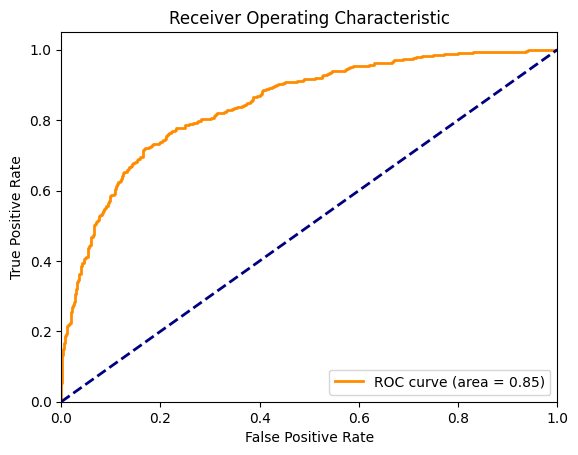

In [ ]:
# Predictions and ROC curve
y_pred = clf.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Accuracy: 0.786875


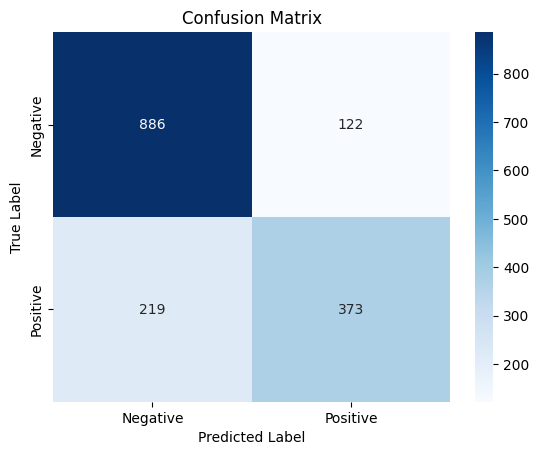

In [ ]:
# Compute accuracy
y_pred_labels = (y_pred > 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred_labels)

print(f"Accuracy: {accuracy}")

# Plot confusion matrix
matrix = confusion_matrix(y_test, y_pred_labels)
plt.figure()
sns.heatmap(matrix, annot=True, cmap='Blues', fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# https://stackoverflow.com/questions/55208734/how-to-save-to-disk-export-a-lightgbm-lgbmregressor-model-trained-in-python
# Save model
clf.save_model('lgbembed.txt', num_iteration=clf.best_iteration)

# Load model
lgbembed = lgb.Booster(model_file='lgbembed.txt')

## Train-Test Boosted Tree with Bag of Words

In [ ]:
param = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "metric": "auc",
    'verbose': -1, # I added this because otherwise it was a bit annoying
}
num_boost_round = 1000

synthetic =False
if synthetic:
  clf=lgb.train(param,training_plus_synthetic_data_bow,num_boost_round=num_boost_round)
else:
  clf = lgb.train(param, train_data_bow, num_boost_round=num_boost_round)


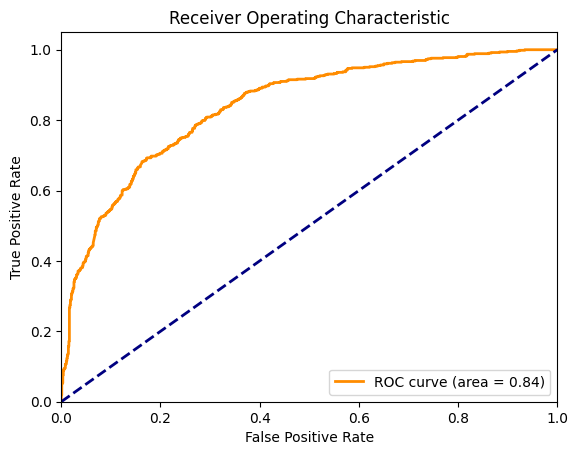

In [ ]:
# Predictions and ROC curve
y_pred_bow = clf.predict(X_test_bow)
fpr, tpr, thresholds = roc_curve(y_test_bow, y_pred_bow)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Accuracy: 0.763125


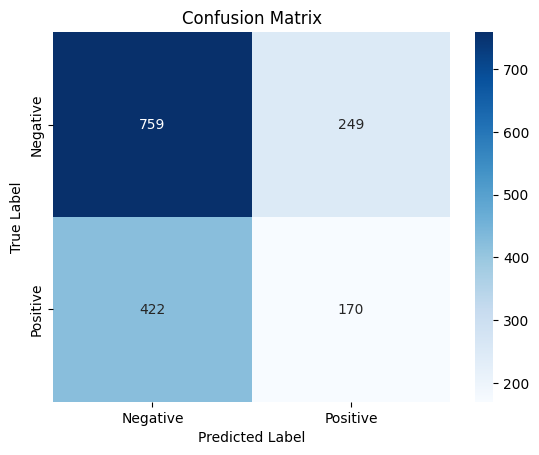

In [ ]:
# Compute accuracy
y_pred_labels = (y_pred_bow > 0.7).astype(int)
accuracy = accuracy_score(y_test_bow, y_pred_labels)

print(f"Accuracy: {accuracy}")

# Plot confusion matrix
matrix = confusion_matrix(y_test, y_pred_labels)
plt.figure()
sns.heatmap(matrix, annot=True, cmap='Blues', fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# https://stackoverflow.com/questions/55208734/how-to-save-to-disk-export-a-lightgbm-lgbmregressor-model-trained-in-python
# Save model
clf.save_model('lgbbow.txt', num_iteration=clf.best_iteration)
# Load model
lgbbow = lgb.Booster(model_file='lgbbow.txt')

## Train-Test LogReg

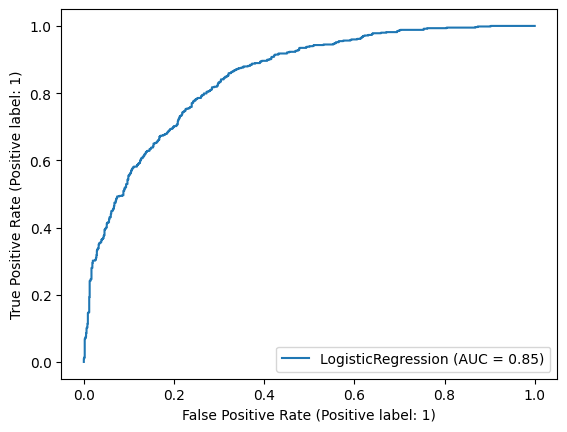

In [ ]:
logreg = LogisticRegression()

# train with synthetic
#logreg.fit(synthetic_embeddings,synthetic_labels)
#train with split
logreg.fit(X_train,y_train)
y_logreg_pred=logreg.predict(X_test)

# Save Model
#pickle.dump(logreg, open(str(MODELS_DIR)+'/'+"logreg_model.pickle", "wb"))

# https://stackoverflow.com/questions/60321389/sklearn-importerror-cannot-import-name-plot-roc-curve
#metrics.plot_roc_curve(logreg,X_test,y_test)
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html#sklearn.metrics.RocCurveDisplay.from_estimator
RocCurveDisplay.from_estimator(logreg, X_test, y_test)
plt.savefig(str(MODELS_DIR)+'/'+'logreg_embedding_roc.png')

In [ ]:
logreg.score(X_test, y_test, sample_weight=None)

0.77125

Accuracy: 0.77125
F1-Score: 0.6737967914438502


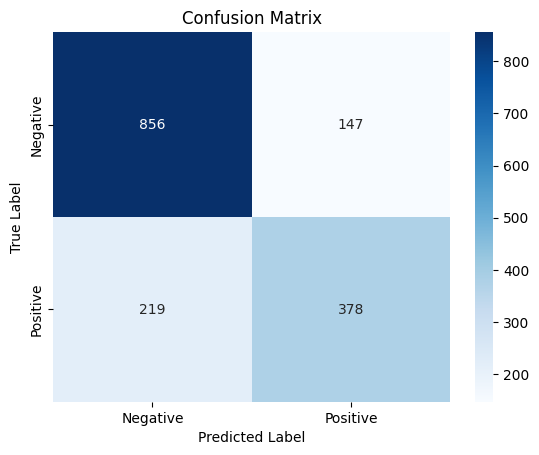

In [ ]:
# Compute accuracy
y_pred_labels = (y_logreg_pred > 0.75).astype(int)
accuracy = accuracy_score(y_test, y_pred_labels)

print(f"Accuracy: {accuracy}")

f1=f1_score(y_test, y_pred_labels)
print(f"F1-Score: {f1}")
# Plot confusion matrix
matrix = confusion_matrix(y_test, y_pred_labels)
plt.figure()
sns.heatmap(matrix, annot=True, cmap='Blues', fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Save model
pickle.dump(logreg, open(str(MODELS_DIR)+'/'+"logreg_embedding.pickle", "wb"))

# Save model
joblib.dump(logreg, str(MODELS_DIR)+'/'+'logreg_embedding.pkl')

['/content/drive/My Drive/Colab Projects/Social Generics with Uwe/Computational Side/Model Training/Saved Models/logreg_embedding.pkl']

## Train-Test LogReg with Bag of Words

In [ ]:
X_train_bow.shape

(6400, 17771)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


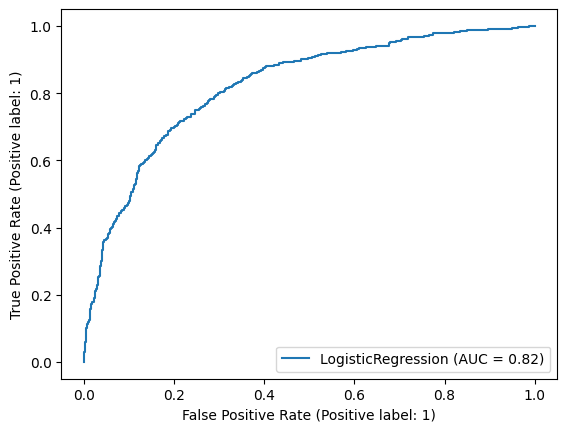

In [ ]:
logreg = LogisticRegression()

# train with synthetic
#logreg.fit(synthetic_X_bow,synthetic_labels)
#train with split
logreg.fit(X_train_bow,y_train_bow)
y_logreg_pred=logreg.predict(X_test_bow)

# Save Model
#pickle.dump(logreg, open(str(MODELS_DIR)+'/'+"logreg_model.pickle", "wb"))

# https://stackoverflow.com/questions/60321389/sklearn-importerror-cannot-import-name-plot-roc-curve
#metrics.plot_roc_curve(logreg,X_test,y_test)
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html#sklearn.metrics.RocCurveDisplay.from_estimator
RocCurveDisplay.from_estimator(logreg, X_test_bow, y_test_bow)
plt.savefig(str(MODELS_DIR)+'/'+'logreg_bow_roc.png')

In [ ]:
logreg.score(X_test_bow, y_test_bow, sample_weight=None)

0.766875

Accuracy: 0.766875
F1-Score: 0.3826530612244898


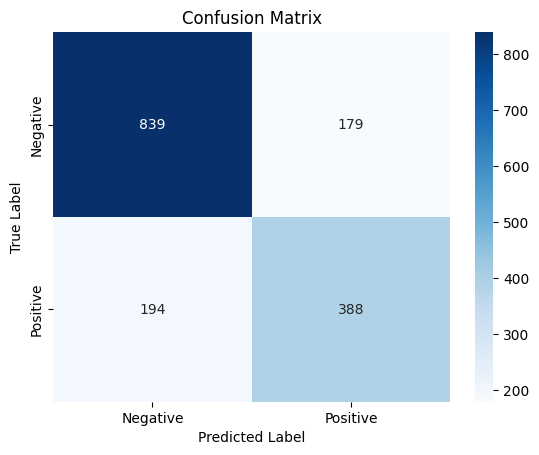

In [ ]:
# Compute accuracy
y_pred_labels = (y_logreg_pred > 0.75).astype(int)
accuracy = accuracy_score(y_test_bow, y_pred_labels)

print(f"Accuracy: {accuracy}")

f1=f1_score(y_test, y_pred_labels)
print(f"F1-Score: {f1}")
# Plot confusion matrix
matrix = confusion_matrix(y_test_bow, y_pred_labels)
plt.figure()
sns.heatmap(matrix, annot=True, cmap='Blues', fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Save model
pickle.dump(logreg, open(str(MODELS_DIR)+'/'+"logreg_bow.pickle", "wb"))

# Save model
joblib.dump(logreg, str(MODELS_DIR)+'/'+'logreg_bow.pkl')

['/content/drive/My Drive/Colab Projects/Social Generics with Uwe/Computational Side/Model Training/Saved Models/logreg_bow.pkl']

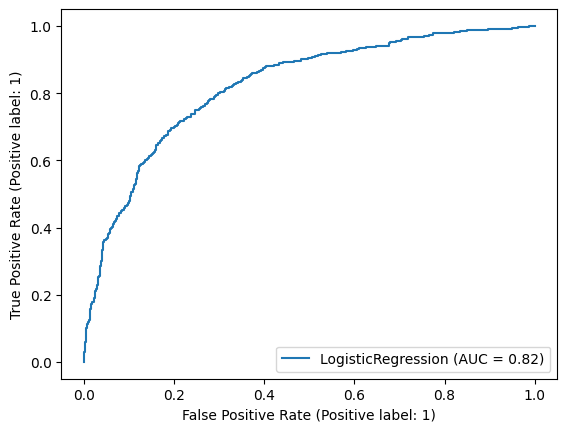

In [ ]:
# Loaded
loaded_logreg_classifier = pickle.load(open(str(MODELS_DIR)+'/'+"logreg_bow.pickle", 'rb'))

RocCurveDisplay.from_estimator(loaded_logreg_classifier, X_test_bow, y_test_bow)

## Helper Functions (Callbacks)

In [ ]:
class AUC_metric(tf.keras.metrics.Metric):
    def __init__(self, name='roc_auc', **kwargs):
        super().__init__(name=name, **kwargs)
        self.auc = tf.keras.metrics.AUC()

    def update_state(self, y_true, y_pred, sample_weight=None):
        class_preds = tf.math.argmax(y_pred, axis=1)
        self.auc.update_state(y_true, class_preds, sample_weight)

    def reset_state(self):
        self.auc.reset_state()

    def result(self):
        return self.auc.result()
auc_metric = AUC_metric()


class F1_metric(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        # Initialize our metric by initializing the two metrics it's based on:
        # Precision and Recall
        self.precision = tf.keras.metrics.Precision()
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Update our metric by updating the two metrics it's based on
        class_preds = tf.math.argmax(y_pred, axis=1)
        self.precision.update_state(y_true, class_preds, sample_weight)
        self.recall.update_state(y_true, class_preds, sample_weight)

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

    def result(self):
        # To get the F1 result, we compute the harmonic mean of the current
        # precision and recall
        return 2 / ((1 / self.precision.result()) + (1 / self.recall.result()))

f1_metric = F1_metric()


# AUC callback
AUC_THRESHOLD = 0.88
class myAccCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        keys = list(logs.keys())
        VAL_AUC = keys[6]
        print("  ")
        #print("The log keys are: {}".format(keys))
        print("The metric we are using is: " + str(VAL_AUC))
        #print('The Validation ROC is: '+str(logs.get(VAL_AUC)))
        #print(str(type(logs.get(VAL_AUC))))
        if(logs.get(VAL_AUC) > AUC_THRESHOLD):
            print("\nReached AUC threshold, so stopping training!!")
            self.model.save_weights(checkpoint_path)
            self.model.stop_training = True

AUC_THRESHOLD = 0.90
acc_callbacks = myAccCallback()


In [ ]:
def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.show()

## Distil Bert Uncased

- https://huggingface.co/distilbert-base-uncased

In [ ]:
# Robert Model Tokenization

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
#tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

synthetic_tokenized_data = tokenizer(synthetic_sentences, return_tensors="np", padding=True)
synthetic_tokenized_data_dict = dict(synthetic_tokenized_data)

tokenized_data = tokenizer(sentences, return_tensors="np", padding=True)
#labels = np.array(labels)  # Label is already an array of 0 and 1
tokenized_data_dict = dict(tokenized_data)

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
## Load Model

# model = AutoModelForMaskedLM.from_pretrained("roberta-base",num_labels=2)
model = TFAutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased',num_labels=2) #bert-base-uncased

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

In [ ]:
## Compile Model
m1 = tf.keras.metrics.BinaryAccuracy()

l1 = 'binary_crossentropy'

# Lower learning rates are often better for fine-tuning transformers
model.compile(loss=l1,optimizer=Adam(3e-5),metrics=[m1,auc_metric,f1_metric])

In [ ]:
# Checkpoint Callback
checkpoint_path = str(MODELS_DIR)+'/'+"/training_hf/DistilledBert/cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,
                                                 verbose=1)

In [ ]:
%%time
history = model.fit(tokenized_data_dict, labels,
                    validation_split=0.2, # This does the train-test split for you!
                    epochs=10,
                    verbose=1,
                    callbacks=[cp_callback,acc_callbacks])

Epoch 1/10
200/200 [==============================] - ETA: 0s - loss: 0.4988 - binary_accuracy: 0.8113 - roc_auc: 0.4571 - f1_score: 0.4571
Epoch 1: saving model to /content/drive/My Drive/Colab Projects/Social Generics with Uwe/Computational Side/Model Training/Saved Models//training_hf/DistilledBert/cp.ckpt
  
The metric we are using is: val_roc_auc
200/200 [==============================] - 87s 331ms/step - loss: 0.4988 - binary_accuracy: 0.8113 - roc_auc: 0.4571 - f1_score: 0.4571 - val_loss: 0.5697 - val_binary_accuracy: 0.8844 - val_roc_auc: 0.1564 - val_f1_score: 0.0724
Epoch 2/10
200/200 [==============================] - ETA: 0s - loss: 0.3353 - binary_accuracy: 0.9016 - roc_auc: 0.4847 - f1_score: 0.4065
Epoch 2: saving model to /content/drive/My Drive/Colab Projects/Social Generics with Uwe/Computational Side/Model Training/Saved Models//training_hf/DistilledBert/cp.ckpt
  
The metric we are using is: val_roc_auc
200/200 [==============================] - 66s 330ms/step - lo

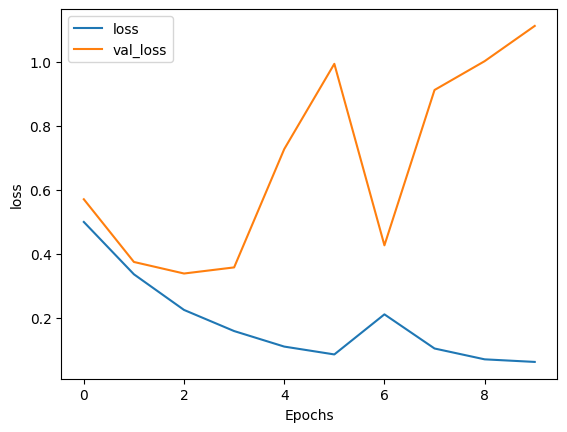

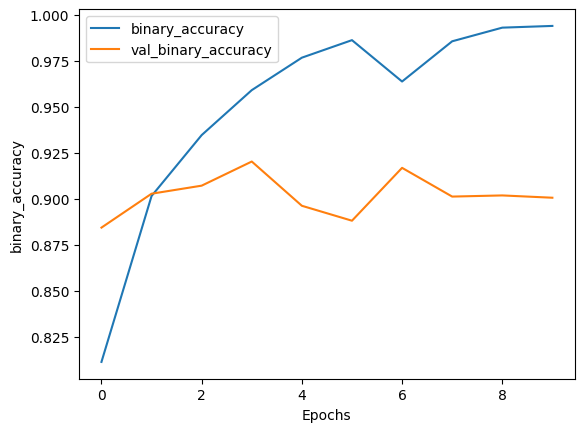

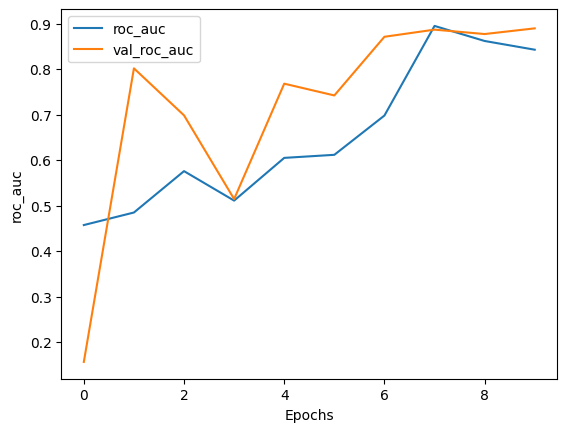

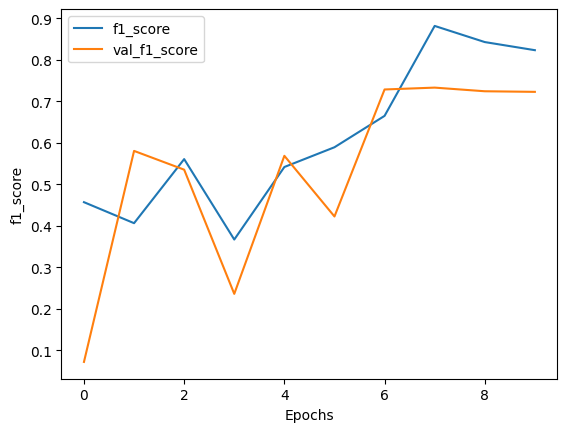

In [ ]:
plot_graphs(history, list(history.history.keys())[0])
plot_graphs(history, list(history.history.keys())[1])
plot_graphs(history, list(history.history.keys())[2])
plot_graphs(history, list(history.history.keys())[3])

## See Plots


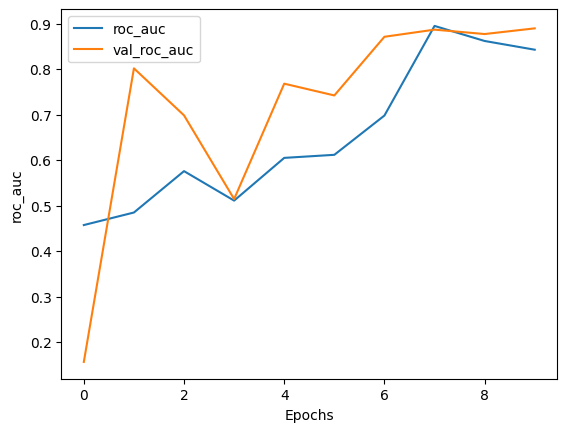

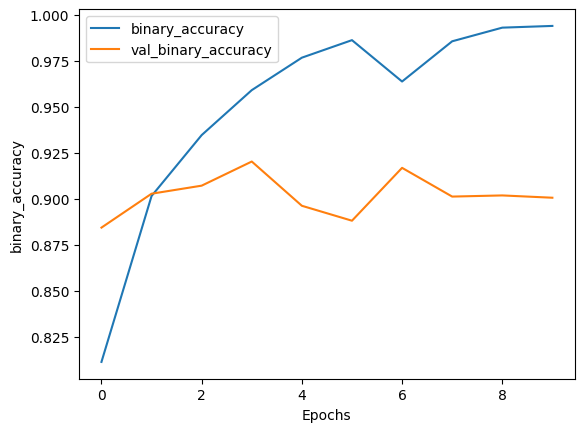

In [ ]:
plot_graphs(history, list(history.history.keys())[2])
plot_graphs(history, list(history.history.keys())[1])

## Train-Test Bert Uncased

https://huggingface.co/bert-base-uncased

- https://huggingface.co/bert-base-uncased/discussions/12

In [ ]:
sentences[0:10]

['people rarely expect an explanation that consists of an actual and complete cause of an event',
 'users overwhelmingly prefer natural language explanations over simple activity labels',
 'humans usually do not build trust in abstract concepts but concrete outputs that they see and can potentially interact with',
 'ordinary americans increasingly dislike and distrust those from the other party',
 'us liberals and conservatives not only disagree on policy issues they are also increasingly unwilling to live near each other be friends or get married to members of the other group',
 'nonnative speakers are generally perceived as less credible and skilled',
 'lx english users are generally subject to linguistic bias in society',
 'people are systematically prejudiced towards members of groups perceived as dissimilar',
 'englishspeakers generally find a patientrole assignment to the texts’ protagonist to be contradictory',
 'politicians rarely change their positions']

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
#tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


synthetic_tokenized_data = tokenizer(synthetic_sentences, return_tensors="np", padding=True)
synthetic_tokenized_data_dict = dict(synthetic_tokenized_data)

tokenized_data = tokenizer(sentences, return_tensors="np", padding=True)
#labels = np.array(labels)  # Label is already an array of 0 and 1
tokenized_data_dict = dict(tokenized_data)

In [ ]:
type(tokenized_data)

transformers.tokenization_utils_base.BatchEncoding

In [ ]:
# Load and compile our model
model = TFAutoModelForSequenceClassification.from_pretrained("bert-base-uncased",num_labels=2) #bert-base-uncased
# model = BertModel.from_pretrained("bert-base-uncased",num_labels=2)
#model = TFBertModel.from_pretrained("bert-base-uncased",num_labels=2)


m1 = tf.keras.metrics.BinaryAccuracy()

l1 = 'binary_crossentropy'

# Lower learning rates are often better for fine-tuning transformers
model.compile(loss=l1,optimizer=Adam(3e-5),metrics=[m1,auc_metric,f1_metric])

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Checkpoint Callback
checkpoint_path = str(MODELS_DIR)+'/'+"/training_hfbert/cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,
                                                 verbose=1)

In [ ]:
%%time
add_synthetic = False
if add_synthetic:
  model.fit(synthetic_tokenized_data_dict, synthetic_labels,
                      validation_split=0.001, # This does the train-test split for you!
                      epochs=5,
                      verbose=1,
                      callbacks=[acc_callbacks,cp_callback])

CPU times: user 5 µs, sys: 1e+03 ns, total: 6 µs
Wall time: 9.78 µs


In [ ]:
%%time
history = model.fit(tokenized_data_dict, labels,
                    validation_split=0.2, # This does the train-test split for you!
                    epochs=10,
                    verbose=1,
                    callbacks=[cp_callback,acc_callbacks])

Epoch 1/10


200/200 [==============================] - ETA: 0s - loss: 0.5959 - binary_accuracy: 0.7888 - roc_auc: 0.2656 - f1_score: 0.2256
Epoch 1: saving model to /content/drive/My Drive/Colab Projects/Social Generics with Uwe/Computational Side/Model Training/Saved Models//training_hfbert/cp.ckpt
  
The metric we are using is: val_roc_auc
200/200 [==============================] - 130s 458ms/step - loss: 0.5959 - binary_accuracy: 0.7888 - roc_auc: 0.2656 - f1_score: 0.2256 - val_loss: 0.4813 - val_binary_accuracy: 0.8753 - val_roc_auc: 0.7230 - val_f1_score: 0.5500
Epoch 2/10
200/200 [==============================] - ETA: 0s - loss: 0.3620 - binary_accuracy: 0.9179 - roc_auc: 0.5466 - f1_score: 0.4860
Epoch 2: saving model to /content/drive/My Drive/Colab Projects/Social Generics with Uwe/Computational Side/Model Training/Saved Models//training_hfbert/cp.ckpt
  
The metric we are using is: val_roc_auc
200/200 [==============================] - 105s 526ms/step - loss: 0.3620 - binary_accuracy:

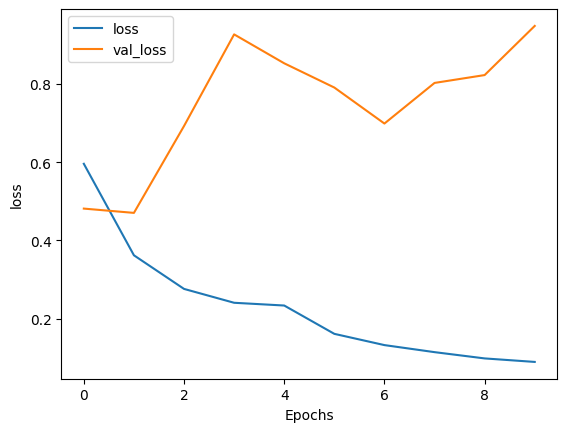

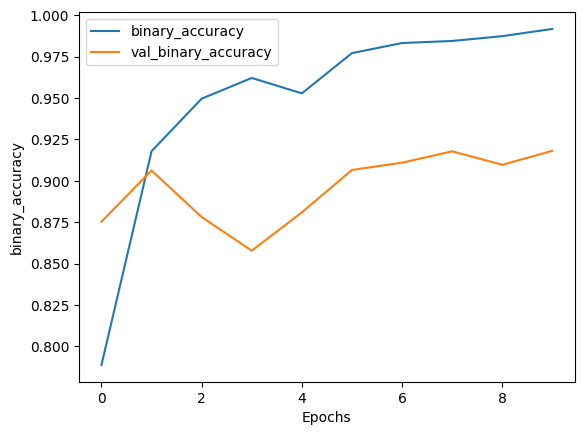

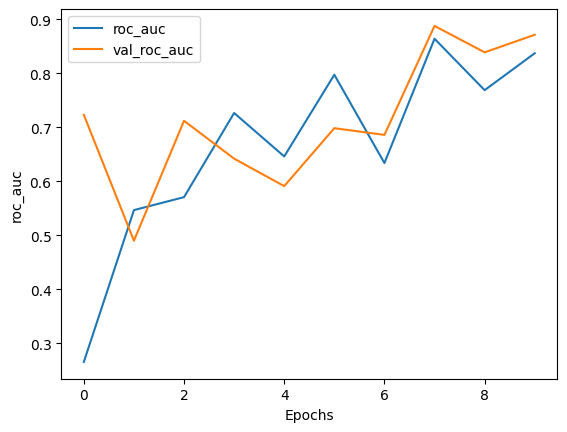

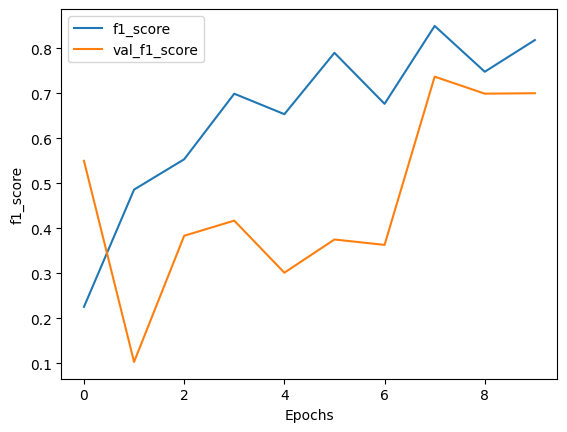

In [ ]:
plot_graphs(history, list(history.history.keys())[0])
plot_graphs(history, list(history.history.keys())[1])
plot_graphs(history, list(history.history.keys())[2])
plot_graphs(history, list(history.history.keys())[3])

In [ ]:
#https://discuss.tensorflow.org/t/model-evaluation-fails-with-too-many-values-to-unpack-expected-2/7095/5
# https://www.tensorflow.org/api_docs/python/tf/keras/Model#evaluate
# Returns the loss value & metrics values for the model in test mode
evaluation1 = model.evaluate(tokenized_data_dict, labels)
evaluation1

250/250 [==============================] - 18s 72ms/step - loss: 0.2530 - binary_accuracy: 0.9791 - roc_auc: 0.9467 - f1_score: 0.9239


[0.2529568076133728,
 0.9791250228881836,
 0.9466840624809265,
 0.9238878488540649]

In [ ]:
# Create a basic model instance
model = TFAutoModelForSequenceClassification.from_pretrained("bert-base-uncased",num_labels=2) #bert-base-uncased
model.compile(loss=l1,optimizer=Adam(3e-5),metrics=[m1,auc_metric,f1_metric])
# Loads the weights
model.load_weights(checkpoint_path)#.expect_partial()

evaluation2 = model.evaluate(tokenized_data_dict, labels)
evaluation2

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


250/250 [==============================] - 22s 72ms/step - loss: 0.2530 - binary_accuracy: 0.9791 - roc_auc: 0.9467 - f1_score: 0.9239


[0.2529568076133728,
 0.9791250228881836,
 0.9466840624809265,
 0.9238878488540649]

In [ ]:
evaluation1==evaluation2

True

## See Plots

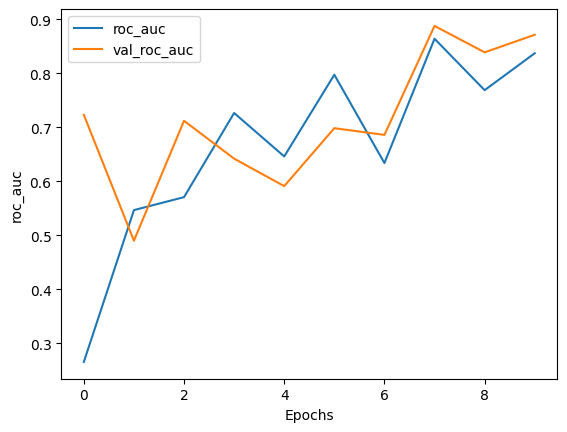

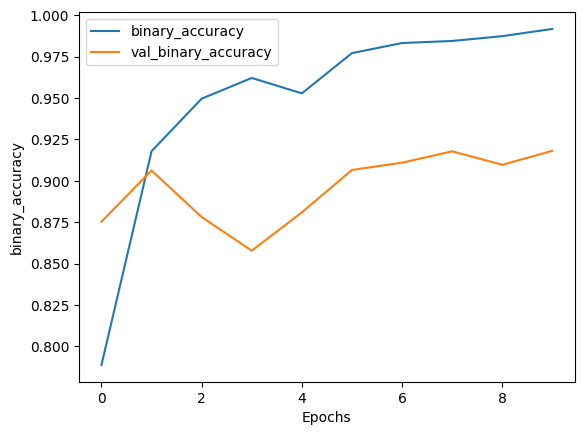

In [ ]:
plot_graphs(history, list(history.history.keys())[2])
plot_graphs(history, list(history.history.keys())[1])

## Robert Model

- https://stackoverflow.com/questions/67047188/need-a-bag-of-words-type-of-transformer

- https://huggingface.co/roberta-base

In [ ]:
# Use a pipeline as a high-level helper
# from transformers import pipeline
# pipe = pipeline("fill-mask", model="roberta-base")

In [ ]:
# Robert Model Tokenization
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
#tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

synthetic_tokenized_data = tokenizer(synthetic_sentences, return_tensors="np", padding=True)
synthetic_tokenized_data_dict = dict(synthetic_tokenized_data)

tokenized_data = tokenizer(sentences, return_tensors="np", padding=True)
#labels = np.array(labels)  # Label is already an array of 0 and 1
tokenized_data_dict = dict(tokenized_data)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
## Load Model

# model = AutoModelForMaskedLM.from_pretrained("roberta-base",num_labels=2)
model = TFAutoModelForSequenceClassification.from_pretrained("roberta-base",num_labels=2) #bert-base-uncased

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

In [ ]:
## Compile Model
m1 = tf.keras.metrics.BinaryAccuracy()

l1 = 'binary_crossentropy'

# Lower learning rates are often better for fine-tuning transformers
model.compile(loss=l1,optimizer=Adam(3e-5),metrics=[m1,auc_metric,f1_metric])

In [ ]:
# Checkpoint Callback
checkpoint_path = str(MODELS_DIR)+'/'+"/training_hf/Robert/cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,
                                                 verbose=1)

In [ ]:
%%time
history = model.fit(tokenized_data_dict, labels,
                    validation_split=0.2, # This does the train-test split for you!
                    epochs=7,
                    verbose=1,
                    callbacks=[cp_callback,acc_callbacks])

Epoch 1/7
200/200 [==============================] - ETA: 0s - loss: 0.6180 - binary_accuracy: 0.7136 - roc_auc: 0.5359 - f1_score: 0.4683 
Epoch 1: saving model to /content/drive/My Drive/Colab Projects/Social Generics with Uwe/Computational Side/Model Training/Saved Models//training_hf/Robert/cp.ckpt
  
The metric we are using is: val_roc_auc
200/200 [==============================] - 5001s 25s/step - loss: 0.6180 - binary_accuracy: 0.7136 - roc_auc: 0.5359 - f1_score: 0.4683 - val_loss: 0.2923 - val_binary_accuracy: 0.9225 - val_roc_auc: 0.4929 - val_f1_score: 0.0075
Epoch 2/7
200/200 [==============================] - ETA: 0s - loss: 0.5413 - binary_accuracy: 0.8210 - roc_auc: 0.5965 - f1_score: 0.5263 
Epoch 2: saving model to /content/drive/My Drive/Colab Projects/Social Generics with Uwe/Computational Side/Model Training/Saved Models//training_hf/Robert/cp.ckpt
  
The metric we are using is: val_roc_auc
200/200 [==============================] - 5005s 25s/step - loss: 0.5413 - b

In [ ]:
plot_graphs(history, list(history.history.keys())[0])
plot_graphs(history, list(history.history.keys())[1])
plot_graphs(history, list(history.history.keys())[2])
plot_graphs(history, list(history.history.keys())[3])

# GZip Classification

- I use this: https://github.com/Sonictherocketman/gzip-classifier
- This is from the paper: https://github.com/bazingagin/npc_gzip/tree/main
- https://medium.com/@heinrichpeters/commentary-gzip-knn-beats-deep-neural-networks-in-text-classification-f395c71283a6
- https://github.com/IgnacioOQ/Simple-kNN-Gzip/blob/main/kNN-gzip-ncd-video-test%20it-deep-learning.ipynb
- https://github.com/Sentdex/Simple-kNN-Gzip/tree/main
- https://openreview.net/attachment?id=_zKlO6euc18&name=pdf
- https://backdrifting.net/post/068_text_classification_gzip

In [ ]:
indices = range(0, len(sentences))
percent = 1-0.2
sample_number = int(len(sentences)/percent)
random_indices = random.sample(indices,sample_number)

In [ ]:
import random

list = [1, 2, 3, 4]
get_index = random.randrange(len(letters))

print(letters[get_index])

In [ ]:
import gzip
import numpy as np
for (x1,_) in test_set:
    Cx1 = len(gzip.compress(x1.encode()))
    distance_from_x1 = []
    for (x2,_) in training_set:
        Cx2 = len(gzip.compress(x2.encode()))
        x1x2 = " ".join([x1,x2])
        Cx1x2 = len(gzip.compress(x1x2.encode()))
        ncd = (Cx1x2 - min(Cx1,Cx2)) / max (Cx1,Cx2)
        distance_from_x1.append(ncd)
    sorted_idx = np.argsort(np.array(distance_from_x1))
    top_k_class = training_set[sorted_idx[:k], 1]
    predict_class = max(set(top_k_class), key = top_k_class.count)

## Original Paper

In [ ]:
!pip install npc-gzip

In [ ]:
# Setup
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(sentences, labels, test_size=0.2)
type(y_test)

In [ ]:
from sklearn.metrics import classification_report
from torchtext.datasets import AG_NEWS

from npc_gzip.compressors.base import BaseCompressor
from npc_gzip.compressors.gzip_compressor import GZipCompressor
from npc_gzip.knn_classifier import KnnClassifier

### Helper Functions

In [ ]:
def fit_model(
    train_text: np.ndarray, train_labels: np.ndarray, distance_metric: str = "ncd"
) -> KnnClassifier:
    """
    Fits a Knn-GZip compressor on the train
    data and returns it.

    Arguments:
        train_text (np.ndarray): Training dataset as a numpy array.
        train_labels (np.ndarray): Training labels as a numpy array.

    Returns:
        KnnClassifier: Trained Knn-Compressor model ready to make predictions.
    """

    compressor: BaseCompressor = GZipCompressor()
    model: KnnClassifier = KnnClassifier(
        compressor=compressor,
        training_inputs=train_text,
        training_labels=train_labels,
        distance_metric=distance_metric,
    )

    return model

In [ ]:
def main(X_train=X_train,y_train=X_train) -> None:
    #print("Fetching data...")
    #((train_text, train_labels), (test_text, test_labels)) = get_data()

    print("Fitting model...")
    model = fit_model(X_train, y_train)
    random_indicies = np.random.choice(X_test.shape[0], 1000, replace=False)

    sample_test_text = X_test[random_indicies]
    sample_test_labels = y_test[random_indicies]

    print("Generating predictions...")
    top_k = 1

    # Here we use the `sampling_percentage` to save time
    # at the expense of worse predictions. This
    # `sampling_percentage` selects a random % of training
    # data to compare `sample_test_text` against rather
    # than comparing it against the entire training dataset.
    (distances, labels, similar_samples) = model.predict(
        sample_test_text, top_k, sampling_percentage=0.01
    )

    print(classification_report(sample_test_labels, labels.reshape(-1)))

### Do the Thing

In [ ]:
main()

## From GitHub

In [ ]:
!pip install git+https://github.com/Sonictherocketman/gzip-classifier

In [ ]:
# Imports
from gzip_classifier import Classifier, ParallelClassifier

In [ ]:
# Try
n=150
small_sent = sentences[0:n]
small_labels=labels[0:n]

classifier = Classifier()
classifier.train(small_sent, small_labels)

print(sentences[n+1])
print(labels[n+1])
print(type(classifier.classify(sentences[n+1], k=20)))
classifier.classify(sentences[n+1])

In [ ]:
# Training
%%time
classifier = Classifier()
#classifier = Classifier()
#classifier.train(X_train, y_train)

with ParallelClassifier(processes=4) as classifier:
    classifier.train(X_train, y_train)

In [ ]:
# Prediction/Classification
%%time
predictions = []
for i in range(len(X_test)):
  score = classifier.classify(X_test[i],k=20)[0]
  predictions.append(score)


predictions=np.array(predictions)
print(type(predictions))
print(predictions[0:10])
print(y_test[0:10])

In [ ]:
# AUC
fpr, tpr, thresholds = metrics.roc_curve(y_test, predictions)
metrics.auc(fpr, tpr)

# aver

# Trash

In [ ]:
import torch
from transformers import RobertaTokenizerFast, RobertaModel
t = RobertaTokenizerFast.from_pretrained('roberta-base')
m = RobertaModel.from_pretrained('roberta-base')
e = m.get_input_embeddings()

tokenized_data = t(sentences, return_tensors="np", padding=True)

In [ ]:
m1 = tf.keras.metrics.BinaryAccuracy()

l1 = 'binary_crossentropy'

# Lower learning rates are often better for fine-tuning transformers
m.compile(loss=l1,optimizer=Adam(3e-5),metrics=[m1,auc_metric,f1_metric])

In [ ]:

synthetic_tokenized_data = tokenizer(synthetic_sentences, return_tensors="np", padding=True)
synthetic_tokenized_data_dict = dict(synthetic_tokenized_data)

tokenized_data = tokenizer(sentences, return_tensors="np", padding=True)
#labels = np.array(labels)  # Label is already an array of 0 and 1
tokenized_data_dict = dict(tokenized_data)

In [ ]:
# tokenized_data = tokenizer(sentences, return_tensors="np", padding=True)
#labels = np.array(labels)  # Label is already an array of 0 and 1
tokenized_data_dict = dict(X_bow)

In [ ]:
# Load and compile our model
model = TFAutoModelForSequenceClassification.from_pretrained("bert-base-uncased",num_labels=2) #bert-base-uncased
# model = BertModel.from_pretrained("bert-base-uncased",num_labels=2)
#model = TFBertModel.from_pretrained("bert-base-uncased",num_labels=2)


m1 = tf.keras.metrics.BinaryAccuracy()

l1 = 'binary_crossentropy'

# Lower learning rates are often better for fine-tuning transformers
model.compile(loss=l1,optimizer=Adam(3e-5),metrics=[m1,auc_metric,f1_metric])

In [ ]:
%%time
history = model.fit(tokenized_data_dict, labels,
                    validation_split=0.2, # This does the train-test split for you!
                    epochs=15,
                    verbose=1,
                    callbacks=[cp_callback,acc_callbacks])

## Para observar

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

synthetic_tokenized_data = tokenizer(synthetic_sentences, return_tensors="np", padding=True)
#synthetic_tokenized_data_dict = dict(synthetic_tokenized_data)

tokenized_data = tokenizer(sentences, return_tensors="np", padding=True)
#labels = np.array(labels)  # Label is already an array of 0 and 1
tokenized_data_dict = dict(tokenized_data)

In [ ]:
plot_graphs(history, list(history.history.keys())[2])